# 05 - PvM Progression Analysis

This notebook extends the OSRS player segmentation project with boss killcount-based PvM progression features.

The previous clustering analysis mainly separated players by skill progression.

In this notebook, the goal is to investigate whether different player progression stages can also be described by boss killcount patterns.

Main research question:

Can OSRS player archetypes be refined by incorporating PvM activity grouped by boss difficulty?

## 1. Import required packages

The following packages are used for:

- data loading,
- numeric transformations,
- feature engineering,
- scaling,
- clustering,
- PCA visualization.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 2. Load raw Hiscores data

For this analysis, the original automatically collected Hiscores dataset is loaded.

This is necessary because the cleaned dataset mainly focused on skill level columns, while this notebook also needs boss killcount columns.

In [7]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
IMAGES_DIR = PROJECT_ROOT / "images"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

raw_input_path = PROCESSED_DATA_DIR / "osrs_hiscores_auto_sample.csv"

df_raw = pd.read_csv(raw_input_path)

df_raw.head()

,player,overall_rank,overall_level,overall_xp,attack_rank,attack_level,attack_xp,defence_rank,defence_level,defence_xp,...,vetion_rank,vetion_kc,vorkath_rank,vorkath_kc,wintertodt_rank,wintertodt_kc,zalcano_rank,zalcano_kc,zulrah_rank,zulrah_kc
0,Obbyy,3691,2376,1059127090,60272,99,25735539,15816,99,32203282,...,6025,2518,4847,2473,203516,25,-1,0,6448,1920
1,Obby Cape,23853,2376,537134823,133254,99,18904741,36445,99,24819279,...,211461,247,128551,261,194068,25,-1,0,56661,475
2,Obby Apples,104613,2278,950095206,101046,99,21090532,136,99,200000000,...,-1,1,-1,1,-1,0,-1,0,-1,0
3,Obby Kenobi,1009416,1752,290653472,-1,1,40,-1,1,0,...,-1,0,-1,0,-1,0,-1,0,-1,0
4,obbE x,25338,2376,521433553,220341,99,15566135,47533,99,22895521,...,300294,164,170439,183,195986,25,46559,9,59787,442


In [8]:
df_raw.shape

(808, 164)

In [9]:
df_raw.columns.tolist()[:50]

['player',
 'overall_rank',
 'overall_level',
 'overall_xp',
 'attack_rank',
 'attack_level',
 'attack_xp',
 'defence_rank',
 'defence_level',
 'defence_xp',
 'strength_rank',
 'strength_level',
 'strength_xp',
 'hitpoints_rank',
 'hitpoints_level',
 'hitpoints_xp',
 'ranged_rank',
 'ranged_level',
 'ranged_xp',
 'prayer_rank',
 'prayer_level',
 'prayer_xp',
 'magic_rank',
 'magic_level',
 'magic_xp',
 'cooking_rank',
 'cooking_level',
 'cooking_xp',
 'woodcutting_rank',
 'woodcutting_level',
 'woodcutting_xp',
 'fletching_rank',
 'fletching_level',
 'fletching_xp',
 'fishing_rank',
 'fishing_level',
 'fishing_xp',
 'firemaking_rank',
 'firemaking_level',
 'firemaking_xp',
 'crafting_rank',
 'crafting_level',
 'crafting_xp',
 'smithing_rank',
 'smithing_level',
 'smithing_xp',
 'mining_rank',
 'mining_level',
 'mining_xp',
 'herblore_rank']

## 3. Identify available boss killcount columns

Boss killcount columns are expected to end with `_kc`.

These columns were parsed from the Hiscores response after the skill section.

In [10]:
boss_kc_columns = [column for column in df_raw.columns if column.endswith("_kc")]

len(boss_kc_columns), boss_kc_columns[:30]

(44,
 ['abyssal_sire_kc',
  'alchemical_hydra_kc',
  'barrows_chests_kc',
  'bryophyta_kc',
  'callisto_kc',
  'cerberus_kc',
  'chambers_of_xeric_kc',
  'chambers_of_xeric_challenge_mode_kc',
  'chaos_elemental_kc',
  'chaos_fanatic_kc',
  'commander_zilyana_kc',
  'corporeal_beast_kc',
  'crazy_archaeologist_kc',
  'dagannoth_prime_kc',
  'dagannoth_rex_kc',
  'dagannoth_supreme_kc',
  'deranged_archaeologist_kc',
  'general_graardor_kc',
  'giant_mole_kc',
  'grotesque_guardians_kc',
  'hespori_kc',
  'kalphite_queen_kc',
  'king_black_dragon_kc',
  'kraken_kc',
  'kreearra_kc',
  'kril_tsutsaroth_kc',
  'mimic_kc',
  'nightmare_kc',
  'obor_kc',
  'sarachnis_kc'])

## 4. Clean boss killcount values

In Hiscores data, `-1` usually means that a player is not ranked for that boss or activity.

For killcount-based analysis, these values are replaced with 0 because an unranked boss entry can be interpreted as no meaningful recorded killcount.

In [11]:
df_boss = df_raw[["player"] + boss_kc_columns].copy()

df_boss[boss_kc_columns] = df_boss[boss_kc_columns].replace(-1, 0)

df_boss.head()

,player,abyssal_sire_kc,alchemical_hydra_kc,barrows_chests_kc,bryophyta_kc,callisto_kc,cerberus_kc,chambers_of_xeric_kc,chambers_of_xeric_challenge_mode_kc,chaos_elemental_kc,...,theatre_of_blood_kc,thermonuclear_smoke_devil_kc,tzkal_zuk_kc,tztok_jad_kc,venenatis_kc,vetion_kc,vorkath_kc,wintertodt_kc,zalcano_kc,zulrah_kc
0,Obbyy,0,0,0,0,0,15,0,2064,815,...,26,473,53,197,2446,2518,2473,25,0,1920
1,Obby Cape,0,0,0,29,3,0,0,2190,765,...,260,1056,0,255,184,247,261,25,0,475
2,Obby Apples,0,0,0,0,0,4,2,75,0,...,4,64,15,2,1,1,1,0,0,0
3,Obby Kenobi,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,obbE x,0,0,0,0,0,0,0,919,65,...,25,55,27,48,178,164,183,25,9,442


## 5. Group bosses by PvM difficulty

Instead of using every boss killcount separately, bosses are grouped into difficulty categories.

This makes the analysis more interpretable.

The categories are:

- early PvM,
- midgame PvM,
- endgame PvM,
- raids.

In [12]:
early_pvm_bosses = [
    "barrows_chests_kc",
    "giant_mole_kc",
    "hespori_kc",
    "wintertodt_kc",
    "tempoross_kc",
    "bryophyta_kc",
    "obor_kc",
    "king_black_dragon_kc"
]

midgame_pvm_bosses = [
    "zulrah_kc",
    "vorkath_kc",
    "kraken_kc",
    "sarachnis_kc",
    "grotesque_guardians_kc",
    "dagannoth_prime_kc",
    "dagannoth_rex_kc",
    "dagannoth_supreme_kc",
    "kalphite_queen_kc",
    "skotizo_kc"
]

endgame_pvm_bosses = [
    "cerberus_kc",
    "alchemical_hydra_kc",
    "the_gauntlet_kc",
    "the_corrupted_gauntlet_kc",
    "nex_kc",
    "nightmare_kc",
    "phosanis_nightmare_kc",
    "phantom_muspah_kc",
    "tzkal_zuk_kc"
]

raid_bosses = [
    "chambers_of_xeric_kc",
    "chambers_of_xeric_challenge_mode_kc",
    "theatre_of_blood_kc",
    "tombs_of_amascut_kc",
    "tombs_of_amascut_expert_kc"
]

In [13]:
def keep_existing_columns(columns, dataframe):
    """
    Keep only columns that exist in the dataframe.
    This prevents errors if some bosses are not available in the current dataset.
    """
    return [column for column in columns if column in dataframe.columns]

In [14]:
early_pvm_bosses = keep_existing_columns(early_pvm_bosses, df_boss)
midgame_pvm_bosses = keep_existing_columns(midgame_pvm_bosses, df_boss)
endgame_pvm_bosses = keep_existing_columns(endgame_pvm_bosses, df_boss)
raid_bosses = keep_existing_columns(raid_bosses, df_boss)

early_pvm_bosses, midgame_pvm_bosses, endgame_pvm_bosses, raid_bosses

(['barrows_chests_kc',
  'giant_mole_kc',
  'hespori_kc',
  'wintertodt_kc',
  'bryophyta_kc',
  'obor_kc',
  'king_black_dragon_kc'],
 ['zulrah_kc',
  'vorkath_kc',
  'kraken_kc',
  'sarachnis_kc',
  'grotesque_guardians_kc',
  'dagannoth_prime_kc',
  'dagannoth_rex_kc',
  'dagannoth_supreme_kc',
  'kalphite_queen_kc',
  'skotizo_kc'],
 ['cerberus_kc',
  'alchemical_hydra_kc',
  'the_gauntlet_kc',
  'the_corrupted_gauntlet_kc',
  'nightmare_kc',
  'tzkal_zuk_kc'],
 ['chambers_of_xeric_kc',
  'chambers_of_xeric_challenge_mode_kc',
  'theatre_of_blood_kc'])

## 6. Apply logarithmic transformation

Boss killcounts are usually highly skewed.

Some players may have thousands of kills at a boss, while many others have zero.

To reduce the effect of extreme values, `log1p` transformation is applied before aggregation.

In [15]:
df_boss_log = df_boss.copy()

df_boss_log[boss_kc_columns] = np.log1p(df_boss_log[boss_kc_columns])

df_boss_log.head()

,player,abyssal_sire_kc,alchemical_hydra_kc,barrows_chests_kc,bryophyta_kc,callisto_kc,cerberus_kc,chambers_of_xeric_kc,chambers_of_xeric_challenge_mode_kc,chaos_elemental_kc,...,theatre_of_blood_kc,thermonuclear_smoke_devil_kc,tzkal_zuk_kc,tztok_jad_kc,venenatis_kc,vetion_kc,vorkath_kc,wintertodt_kc,zalcano_kc,zulrah_kc
0,Obbyy,0.0,0.0,0.0,0.000000,0.000000,2.772589,0.000000,7.632886,6.704414,...,3.295837,6.161207,3.988984,5.288267,7.802618,7.831617,7.813592,3.258097,0.000000,7.560601
1,Obby Cape,0.0,0.0,0.0,3.401197,1.386294,0.000000,0.000000,7.692113,6.641182,...,5.564520,6.963190,0.000000,5.545177,5.220356,5.513429,5.568345,3.258097,0.000000,6.165418
2,Obby Apples,0.0,0.0,0.0,0.000000,0.000000,1.609438,1.098612,4.330733,0.000000,...,1.609438,4.174387,2.772589,1.098612,0.693147,0.693147,0.693147,0.000000,0.000000,0.000000
3,Obby Kenobi,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,obbE x,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,6.824374,4.189655,...,3.258097,4.025352,3.332205,3.891820,5.187386,5.105945,5.214936,3.258097,2.302585,6.093570


## 7. Create PvM progression features

Aggregated PvM features are created from boss difficulty groups.

These features describe the type and level of PvM activity for each player.

In [16]:
df_pvm = df_boss[["player"]].copy()

df_pvm["early_pvm_score"] = df_boss_log[early_pvm_bosses].sum(axis=1) if early_pvm_bosses else 0
df_pvm["midgame_pvm_score"] = df_boss_log[midgame_pvm_bosses].sum(axis=1) if midgame_pvm_bosses else 0
df_pvm["endgame_pvm_score"] = df_boss_log[endgame_pvm_bosses].sum(axis=1) if endgame_pvm_bosses else 0
df_pvm["raid_pvm_score"] = df_boss_log[raid_bosses].sum(axis=1) if raid_bosses else 0

df_pvm["total_pvm_score"] = (
    df_pvm["early_pvm_score"]
    + df_pvm["midgame_pvm_score"]
    + df_pvm["endgame_pvm_score"]
    + df_pvm["raid_pvm_score"]
)

df_pvm.head()

,player,early_pvm_score,midgame_pvm_score,endgame_pvm_score,raid_pvm_score,total_pvm_score
0,Obbyy,25.733750,53.187074,12.852883,10.928722,102.702430
1,Obby Cape,32.458212,62.812116,11.778439,13.256634,120.305400
2,Obby Apples,2.484907,18.604069,7.937375,7.038784,36.065134
3,Obby Kenobi,0.000000,12.399157,0.000000,0.693147,13.092304
4,obbE x,22.508774,60.590075,15.232893,10.082470,108.414212


## 8. Load skill-based cleaned dataset

The skill-based cleaned dataset is loaded and merged with the PvM progression features.

In [17]:
skill_input_path = PROCESSED_DATA_DIR / "osrs_hiscores_cleaned.csv"

df_skill = pd.read_csv(skill_input_path)

df_skill.head()

,player,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,...,construction,sailing,combat_score,gathering_score,production_score,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std
0,Obbyy,2376,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000
1,Obby Cape,2376,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000
2,Obby Apples,2278,99,99,99,99,99,99,99,99,...,99,1,99.000000,79.4,99.00,99.0,94.916667,99,1,20.004166
3,Obby Kenobi,1752,1,1,99,90,65,31,60,99,...,75,99,49.571429,91.4,82.25,72.5,73.000000,99,1,27.700259
4,obbE x,2376,99,99,99,99,99,99,99,99,...,99,99,99.000000,99.0,99.00,99.0,99.000000,99,99,0.000000


In [18]:
df_combined = df_skill.merge(df_pvm, on="player", how="inner")

df_combined.head()

,player,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,...,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std,early_pvm_score,midgame_pvm_score,endgame_pvm_score,raid_pvm_score,total_pvm_score
0,Obbyy,2376,99,99,99,99,99,99,99,99,...,99.0,99.000000,99,99,0.000000,25.733750,53.187074,12.852883,10.928722,102.702430
1,Obby Cape,2376,99,99,99,99,99,99,99,99,...,99.0,99.000000,99,99,0.000000,32.458212,62.812116,11.778439,13.256634,120.305400
2,Obby Apples,2278,99,99,99,99,99,99,99,99,...,99.0,94.916667,99,1,20.004166,2.484907,18.604069,7.937375,7.038784,36.065134
3,Obby Kenobi,1752,1,1,99,90,65,31,60,99,...,72.5,73.000000,99,1,27.700259,0.000000,12.399157,0.000000,0.693147,13.092304
4,obbE x,2376,99,99,99,99,99,99,99,99,...,99.0,99.000000,99,99,0.000000,22.508774,60.590075,15.232893,10.082470,108.414212


In [19]:
df_combined.shape

(808, 39)

## 9. Create clustering feature matrix

The clustering model now uses both skill progression and PvM progression features.

The `player` column is excluded because it is only an identifier.

In [20]:
feature_columns = [column for column in df_combined.columns if column != "player"]

X = df_combined[feature_columns].copy()

X.head()

,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,woodcutting,...,support_score,average_skill_level,max_skill_level,min_skill_level,skill_level_std,early_pvm_score,midgame_pvm_score,endgame_pvm_score,raid_pvm_score,total_pvm_score
0,2376,99,99,99,99,99,99,99,99,99,...,99.0,99.000000,99,99,0.000000,25.733750,53.187074,12.852883,10.928722,102.702430
1,2376,99,99,99,99,99,99,99,99,99,...,99.0,99.000000,99,99,0.000000,32.458212,62.812116,11.778439,13.256634,120.305400
2,2278,99,99,99,99,99,99,99,99,99,...,99.0,94.916667,99,1,20.004166,2.484907,18.604069,7.937375,7.038784,36.065134
3,1752,1,1,99,90,65,31,60,99,99,...,72.5,73.000000,99,1,27.700259,0.000000,12.399157,0.000000,0.693147,13.092304
4,2376,99,99,99,99,99,99,99,99,99,...,99.0,99.000000,99,99,0.000000,22.508774,60.590075,15.232893,10.082470,108.414212


## 10. Scale combined features

Since skill features and PvM scores are on different scales, StandardScaler is applied before clustering.

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 6.14504155e-01,  4.40211681e-01,  4.63407796e-01,
         3.57260115e-01,  3.61297906e-01,  3.75759403e-01,
         5.99304591e-01,  3.84684615e-01,  4.49984756e-01,
         5.06645928e-01,  5.29801575e-01,  5.37208190e-01,
         4.94779898e-01,  5.18563072e-01,  6.12545271e-01,
         5.30173046e-01,  5.69994777e-01,  6.37003970e-01,
         5.77362694e-01,  4.88321007e-01,  4.86118317e-01,
         6.81015495e-01,  6.32871674e-01,  6.16813156e-01,
         1.11907586e+00,  4.58372003e-01,  8.52707205e-01,
         5.98506413e-01,  5.68156219e-01,  6.40988395e-01,
         2.38644381e-01,  1.21874383e+00, -1.11720191e+00,
         1.03835486e+00,  8.74725185e-01,  7.95801791e-01,
         7.80117078e-01,  9.51332506e-01],
       [ 6.14504155e-01,  4.40211681e-01,  4.63407796e-01,
         3.57260115e-01,  3.61297906e-01,  3.75759403e-01,
         5.99304591e-01,  3.84684615e-01,  4.49984756e-01,
         5.06645928e-01,  5.29801575e-01,  5.37208190e-01,
         4.94

## 11. Determine cluster number with Elbow Method and Silhouette Score

The same evaluation logic is applied as in the previous clustering notebook.

In [22]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

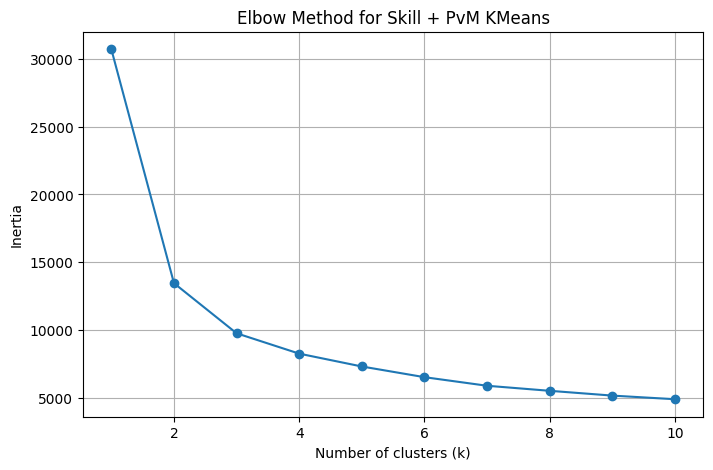

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.title("Elbow Method for Skill + PvM KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)

plt.show()

In [24]:
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

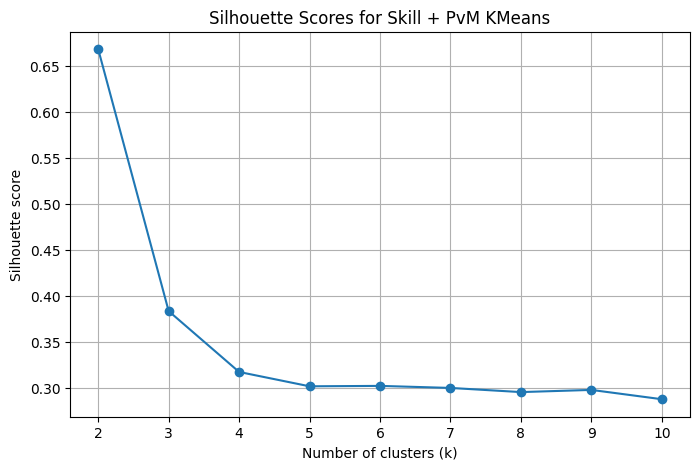

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Scores for Skill + PvM KMeans")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.grid(True)

plt.show()

## 12. Fit final Skill + PvM KMeans model

The selected number of clusters can be adjusted after reviewing the Elbow and Silhouette plots.

In [26]:
selected_k = 3

In [27]:
kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

df_combined_clustered = df_combined.copy()
df_combined_clustered["skill_pvm_cluster"] = labels

df_combined_clustered.head()

,player,overall,attack,defence,strength,hitpoints,ranged,prayer,magic,cooking,...,average_skill_level,max_skill_level,min_skill_level,skill_level_std,early_pvm_score,midgame_pvm_score,endgame_pvm_score,raid_pvm_score,total_pvm_score,skill_pvm_cluster
0,Obbyy,2376,99,99,99,99,99,99,99,99,...,99.000000,99,99,0.000000,25.733750,53.187074,12.852883,10.928722,102.702430,0
1,Obby Cape,2376,99,99,99,99,99,99,99,99,...,99.000000,99,99,0.000000,32.458212,62.812116,11.778439,13.256634,120.305400,0
2,Obby Apples,2278,99,99,99,99,99,99,99,99,...,94.916667,99,1,20.004166,2.484907,18.604069,7.937375,7.038784,36.065134,2
3,Obby Kenobi,1752,1,1,99,90,65,31,60,99,...,73.000000,99,1,27.700259,0.000000,12.399157,0.000000,0.693147,13.092304,2
4,obbE x,2376,99,99,99,99,99,99,99,99,...,99.000000,99,99,0.000000,22.508774,60.590075,15.232893,10.082470,108.414212,0


In [28]:
df_combined_clustered["skill_pvm_cluster"].value_counts().sort_index()

skill_pvm_cluster
0    476
1     82
2    250
Name: count, dtype: int64

## 13. Visualize Skill + PvM clusters with PCA

PCA is used to visualize the combined skill and PvM feature space in two dimensions.

In [29]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "player": df_combined["player"],
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1],
    "skill_pvm_cluster": labels
})

explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")

PC1 explained variance: 72.28%
PC2 explained variance: 8.53%
Total explained variance: 80.81%


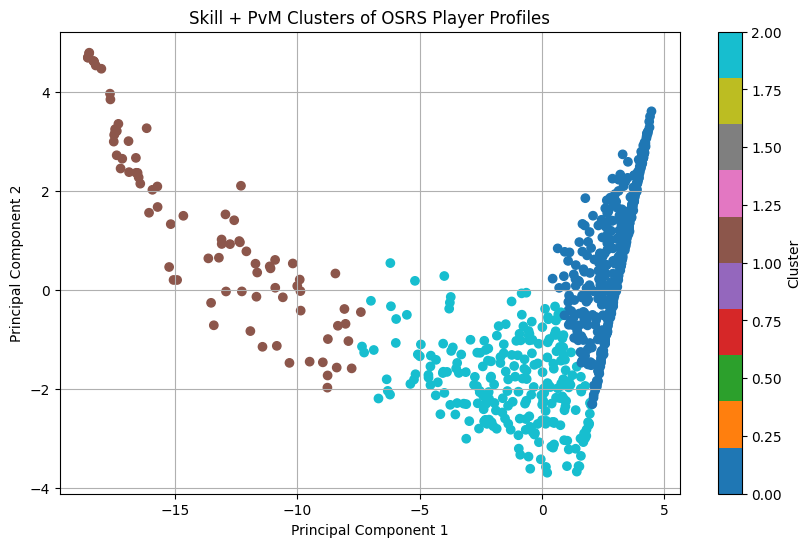

In [30]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_pca["pca_1"],
    df_pca["pca_2"],
    c=df_pca["skill_pvm_cluster"],
    cmap="tab10"
)

plt.title("Skill + PvM Clusters of OSRS Player Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")

plt.show()

## 14. Interpret Skill + PvM clusters

Cluster profiles are calculated to understand how the groups differ in both skill progression and PvM activity.

In [31]:
cluster_profile = df_combined_clustered.groupby("skill_pvm_cluster")[feature_columns].mean()

important_profile_columns = [
    "overall",
    "combat_score",
    "gathering_score",
    "production_score",
    "support_score",
    "average_skill_level",
    "skill_level_std",
    "early_pvm_score",
    "midgame_pvm_score",
    "endgame_pvm_score",
    "raid_pvm_score",
    "total_pvm_score"
]

important_profile_columns = [
    column for column in important_profile_columns
    if column in cluster_profile.columns
]

cluster_profile[important_profile_columns]

,overall,combat_score,gathering_score,production_score,support_score,average_skill_level,skill_level_std,early_pvm_score,midgame_pvm_score,endgame_pvm_score,raid_pvm_score,total_pvm_score
skill_pvm_cluster,,,,,,,,,,,,
0,2314.052521,98.366447,92.436975,96.792279,97.241071,96.418855,5.833890,20.754031,48.714590,11.125440,10.191093,90.785154
1,473.426829,30.135889,18.580488,21.128049,18.881098,22.850102,24.431082,0.267979,4.582265,0.159628,0.879489,5.889360
2,1944.732000,86.553714,69.836800,82.024000,82.193000,80.834333,19.405968,3.888912,19.232678,2.596614,4.919525,30.637729


## 15. Save Skill + PvM clustering results

The final dataset with Skill + PvM cluster labels is saved for later reporting.

In [32]:
output_path = PROCESSED_DATA_DIR / "osrs_hiscores_skill_pvm_clustered.csv"

df_combined_clustered.to_csv(output_path, index=False, encoding="utf-8")

output_path

WindowsPath('C:/Projects/osrs-player-segmentation/data/processed/osrs_hiscores_skill_pvm_clustered.csv')

## Summary

This notebook extended the OSRS player segmentation project by incorporating PvM progression features.

The main steps were:

- extracting boss killcount columns,
- replacing unranked values with zero,
- grouping bosses by difficulty,
- applying logarithmic transformation to killcounts,
- creating early, midgame, endgame and raid PvM scores,
- merging PvM features with skill progression features,
- applying KMeans clustering,
- visualizing the combined feature space with PCA,
- interpreting clusters based on both skills and PvM activity.

This extension makes the player archetype analysis more informative because it separates not only player skill progression, but also PvM behavior and bossing maturity.